# **Implementation Notebook: Feature Engineering and Machine Learning Framework for Gearbox Fault Diagnosis**


## Notebook Structure

This notebook provides the complete implementation of the proposed vibration-based fault diagnosis framework described in the manuscript. It includes data preparation, feature engineering, feature selection, model optimization, and final classification evaluation. The workflow follows the same sequence as the methodology section, enabling full reproducibility of the reported experimental results.

## Table of contents
## The main steps are organized as follows:

**Libraries importation**
   - Importing the necessary libraries and modules

**I. Data Splitting (75% Train / 25% Test)**
   - Loading raw vibration datasets
   - Training/hold-out testing separation
   - Data saving for subsequent processing

**II. Feature extraction and datasets preparation**
   - II-1. Raw data loading (Training and Testing)
   - II-2. Feature extraction function (13 methods)
   - II-3. Raw data segmentation and feature extraction
   - II-4. Extracted data loading
   - II-5. Interleaving extracted data (parallel interleaved method)
   - II-6. Interleaving raw data (parallel interleaved method)

**III. Hyperparameter optimization and feature selection**
   - III-1. Interleaved datasets loading
   - III-2. Preprocessing: detecting and removing constant features (Variance = 0)
   - III-3. Pipeline and Grid Search Cross-Validation
   - III-4. Grid results and metrics displaying
   - III-5. Stability (Feature frequency voting)
   - III-6. Feature correlation (stable features filtering)

**IV. Statistical and frequency analysis of the raw vibration signals**
   - Raw vibration signals loading
   - Statistical and frequencial descriptor computation of raw signals (a1–a4)
   - Saving the results

**V. Final Machine Learning Classification**
   - V-1. Datasets loading
   - V-2. ML Prediction for raw and all extracted data (no feature selection)
   - V-3. ML Prediction for the selected, stable, and final retained features
   - V-4. Classification reports and confusion matrices results displaying

**------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**

## **Libraries importation**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import kurtosis, skew
from scipy.fftpack import fft
from scipy.signal import welch

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score, recall_score, accuracy_score, precision_score
)

import matplotlib.pyplot as plt
from matplotlib import cm

import warnings
warnings.filterwarnings("ignore")

## **I. Data Splitting (75% Train / 25% Test)**

In [ ]:
Raw_healthy_data=[]
Raw_broken_data=[]

for i in range(10):
  # Loading the ten raw files for healthy and broken classes
  Raw_healthy_data.append(pd.read_csv('Raw_healthy_load'+str(i)+'0.csv'))
  Raw_broken_data.append(pd.read_csv('Raw_broken_load'+str(i)+'0.csv'))

  # Note: here, the 10 healthy/broken files are renamed as:
  # Raw_healthy_load00, Raw_healthy_load10, ..., Raw_healthy_load90
  # Raw_broken_load00, Raw_broken_load10, ..., Raw_broken_load90

  train_size = int(len(Raw_healthy_data[i]) * 0.75)
  train_data = Raw_healthy_data[i].iloc[:train_size]
  test_data = Raw_healthy_data[i].iloc[train_size:]

  # Saving healthy data (training and testing)
  train_data.to_csv('Raw_healthy_load'+str(i)+'0_Train.csv', index=False)
  test_data.to_csv('Raw_healthy_load'+str(i)+'0_Test.csv', index=False)

  train_size = int(len(Raw_broken_data[i]) * 0.75)
  train_data = Raw_broken_data[i].iloc[:train_size]
  test_data = Raw_broken_data[i].iloc[train_size:]

  # Saving broken data (training and testing)
  train_data.to_csv('Raw_broken_load'+str(i)+'0_Train.csv', index=False)
  test_data.to_csv('Raw_broken_load'+str(i)+'0_Test.csv', index=False)

## **II. Feature extraction and datasets preparation**

### **II-1. Raw data loading (Training and Testing)**

In [ ]:
Raw_healthy_data_Train=[]
Raw_healthy_data_Test=[]

Raw_broken_data_Train=[]
Raw_broken_data_Test=[]

for i in range(10):
  Raw_healthy_data_Train.append(pd.read_csv('Raw_healthy_load'+str(i)+'0_Train.csv'))
  Raw_healthy_data_Test.append(pd.read_csv('Raw_healthy_load'+str(i)+'0_Test.csv'))

  Raw_broken_data_Train.append(pd.read_csv('Raw_broken_load'+str(i)+'0_Train.csv'))
  Raw_broken_data_Test.append(pd.read_csv('Raw_broken_load'+str(i)+'0_Test.csv'))

### **II-2. Feature extraction function (13 methods)**

In [ ]:
# Function to calculate features
def extract_features(window):
    features = {}

    for col in ['a1', 'a2', 'a3', 'a4']:
        signal = window[col]

        # Statistical Features
        features[f'Mean_{col}'] = np.mean(signal)
        features[f'StDev_{col}'] = np.sqrt(np.var(signal))
        features[f'Kurtosis_{col}'] = kurtosis(signal)
        features[f'Skewness_{col}'] = skew(signal)
        features[f'RMS_{col}'] = np.sqrt(np.mean(np.square(signal)))
        features[f'Min_{col}'] = np.min(signal)
        features[f'Max_{col}'] = np.max(signal)

        # Time-Domain Features
        features[f'Peak_to_Peak_{col}'] = np.ptp(signal)
        features[f'Crest_Factor_{col}'] = np.max(np.abs(signal)) / features[f'RMS_{col}']
        features[f'Energy_{col}'] = np.sum(np.square(signal))

        # Frequency-Domain Features
        spect = np.abs(fft(signal.to_numpy()))
        features[f'Dominant_Freq_{col}'] = np.argmax(spect[:len(spect)//2])

        Spect_Ent = -np.sum((spect / np.sum(spect)) * np.log(spect / np.sum(spect)))
        features[f'Spectral_Entropy_{col}'] = Spect_Ent

        # Power spectral density
        f, Pxx = welch(signal.to_numpy())
        features[f'PSD_Mean_{col}'] = np.mean(Pxx)

    return features

### **II-3. Raw data segmentation and feature extraction**

In [ ]:
# Set: window size / overlap rate / step_size
window_size = 200
overlap = 0.5
step_size = int(window_size * (1 - overlap))

Extracted_Datasets_Train = []
# or Extracted_Datasets_Test = []

for i in range(10):
    k = 0
    Ext_Data_List = []
    for data in [Raw_healthy_data_Train[i], Raw_broken_data_Train[i]]:
    # or for data in [Raw_healthy_data_Test[i], Raw_broken_data_Test[i]]:

        features_list = [] # List for extracted features

        # Apply sliding window
        for i in range(0, len(data) - window_size + 1, step_size):
            window = data.iloc[i:i + window_size]
            if len(window) == window_size:
                features = extract_features(window)
                features_list.append(features)

        # Convert the extracted features to a DataFrame
        features_df = pd.DataFrame(features_list)

        # Adding the target column (K = 0 (healthy), k = 1 (broken))
        features_df['Failure'] = k

        # Storing all the extracted features and target columns
        Ext_Data_List.append(features_df)
        k+=1

    Extracted_Datasets_Train.append(
        pd.concat([Ext_Data_List[0], Ext_Data_List[1]], ignore_index=True)
        )
    # or Extracted_Datasets_Test.append(
    #        pd.concat([Ext_Data_List[0], Ext_Data_List[1]], ignore_index=True)
    #        )

    # Note: Extracted_Datasets_Train/Test is a list of the 10 extracted healthy-broken datasets:
    # (load 0%, load 10%, ..., load 90% for the training and testing data)

    # Save the extracted data
    Extracted_Datasets_Train[i].to_csv(
        'Extracted_data(healthy-broken)_load-'+str(i)+'0_Train.csv', index=False
        )
    # or Extracted_Datasets_Test[i].to_csv(
    #        'Extracted_data(healthy-broken)_load-'+str(i)+'0_Test.csv', index=False
    #        )

### **II-4. Extracted data loading**

In [ ]:
Extracted_data_Train=[]
Extracted_data_Test=[]

for i in range(10):
  Extracted_data_Train.append(pd.read_csv('Extracted_data(healthy-broken)_load-'+str(i)+'0_Train.csv'))
  Extracted_data_Test.append(pd.read_csv('Extracted_data(healthy-broken)_load-'+str(i)+'0_Test.csv'))

### **II-5. Interleaving extracted data (parallel interleaved method)**

In [ ]:
Interleaved_Ext_data_Train=[]
Interleaved_Ext_data_Test=[]

for i in range(10):
    # 1. Add window_idx within each class
    # This ensures row 0 of Class 0 and row 0 of Class 1 both get index 0
    Extracted_data_Train[i]['window_idx'] = df_loaded.groupby('Failure').cumcount()
    Extracted_data_Test[i]['window_idx'] = df_loaded.groupby('Failure').cumcount()

    # 2. Interleave: Sort by window_idx (time) first, then class_id
    Interleaved_Ext_data_Train.append(Extracted_data_Train[i].sort_values(by=['window_idx', 'Failure']).reset_index(drop=True))
    Interleaved_Ext_data_Test.append(Extracted_data_Test[i].sort_values(by=['window_idx', 'Failure']).reset_index(drop=True))

    # 3. Saving the interleaved extracted data
    Interleaved_Ext_data_Train.to_csv('Interleaved_Ext_data(healthy-broken)_load-'+str(i)+'0_Train.csv', index=False)
    Interleaved_Ext_data_Test.to_csv('Interleaved_Ext_data(healthy-broken)_load-'+str(i)+'0_Test.csv', index=False)

### **II-6. Interleaving raw data (parallel interleaved method)**

In [ ]:
Raw_data_Train = []
Raw_data_Test = []

Interleved_Raw_data_Train = []
Interleved_Raw_data_Test = []

for i in range(10):
   # ----------------------------raw dataset construction---------------------------------

    # Adding the Failure column (target) to the raw signals
    Raw_healthy_data_Train[i]['Failure'] = 0
    Raw_broken_data_Train[i]['Failure'] = 1
    Raw_healthy_data_Test[i]['Failure'] = 0
    Raw_broken_data_Test[i]['Failure'] = 1

    # Concatinating healthy and broken data for each load condition (for training and testing data)
    Raw_data_Train.append(pd.concat([Raw_healthy_data_Train[i], Raw_broken_data_Train[i]], ignore_index=True))
    Raw_data_Test.append(pd.concat([Raw_healthy_data_Test[i], Raw_broken_data_Test], ignore_index=True))

    # ----------------------------Interleaving raw data---------------------------------

    # 1. Add window_idx within each class
    # This ensures row 0 of Class 0 and row 0 of Class 1 both get index 0
    Raw_data_Train[i]['window_idx'] = Raw_data_Train[i].groupby('Failure').cumcount()
    Raw_data_Test[i]['window_idx'] = Raw_data_Test[i].groupby('Failure').cumcount()

    # 2. Interleave: Sort by window_idx (time) first, then class_id
    Interleved_Raw_data_Train.append(Raw_data_Train[i].sort_values(by=['window_idx', 'Failure']).reset_index(drop=True))
    Interleved_Raw_data_Test.append(Raw_data_Test[i].sort_values(by=['window_idx', 'Failure']).reset_index(drop=True))

    # 3. Saving the interleaved raw data
    Interleved_Raw_data_Train[i].to_csv('Interleaved_Raw_data(healthy-broken)_load-'+str(i)+'0_Train.csv', index=False)
    Interleved_Raw_data_Test[i].to_csv('Interleaved_Raw_data(healthy-broken)_load-'+str(i)+'0_Test.csv', index=False)

## **III. Hyperparameters optimization and feature selection**

### **III-1. Interleaved datasets loading**

In [ ]:
# Note: the selection workflow is applied only on the training set
# The pipeline will be applied on the training dataset for each independant load
# Supposing, for example, that we will work with load 40%

# For Extracted datasets:
dataset_Train = pd.read_csv('Interleaved_Ext_data(healthy-broken)_load-40_Train.csv')

# For Raw datasets:
# Code: dataset_Train = pd.read_csv('Interleaved_Raw_data(healthy-broken)_load-40_Train.csv')
# This is for the raw ablation phase: when applying the pipline on raw signals

X_Train = dataset_Train.drop(columns=['Failure', 'window_idx'])
y_Train = dataset_Train['Failure']

### **III-2. Preprocessing: detecting and removing constant features (Variance = 0)**

In [ ]:
X=X_Train

from sklearn.feature_selection import VarianceThreshold

# Keep original feature names
feature_names = X.columns

# Detect constant columns (variance = 0)
selector_const = VarianceThreshold(threshold=0)

selector_const.fit(X)

# Boolean mask
mask = selector_const.get_support()

# Constant feature names
constant_features = feature_names[~mask]

print("\n==============================")
print("CONSTANT FEATURES")
print("==============================")

for feat in constant_features:
    print(feat)

# Remove constant features
X = X.loc[:, mask]

print("\nNew shape after removing constants:")
print(X.shape)

feature_names = X.columns

### **III-3. Pipeline and Grid Search Cross-Validation**

In [ ]:
# Intitializing: TSCV, RF, and SVM
tscv = TimeSeriesSplit(n_splits=5, gap=2)

rf = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
    )
svm = SVC(C=1, random_state=42)

# Pipline initialization
pipeline = Pipeline([
    ('scaler', StandardScaler()), # Standardizing data
    ('smote', SMOTE(random_state=42)), # Balancing data
    ('selector', SelectKBest(score_func=f_classif, k=10)), # Initializing SelectKBest function
    # 'selector' is disabled for raw and all extracted features ablation phases (no feature selection)
    ('classifier', rf) # or ('classifier', svm)
])
# RF Hyperparameters Tuning (for k = 1, 2, ..., 10)
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10],
    'classifier__max_features': ['sqrt', 'log2'],
    'selector__k': list(range(1, 11))
    # 'selector__k' is disabled for raw and all extracted features ablation phases (no feature selection)
    }

# SVM Hyperparameters Tuning (for k = 1, 2, ..., 10)
param_grid_svm = {
    'classifier__C': [1.0, 0.01, 0.1, 1, 10, 100],
    'classifier__kernel': ['rbf', 'linear'],
    'classifier__gamma': ['scale', 'auto'],
    'selector__k': list(range(1, 11))
    # 'selector__k' is disabled for raw and all extracted features ablation phases (no feature selection)
    }

#param_grid_model = param_grid_rf or param_grid_svm
grid = GridSearchCV(
    estimator=pipeline, param_grid=param_grid_model,
    cv=tscv, scoring='f1', n_jobs=-1, verbose=2
    )
grid.fit(X_Train, y_Train) # Training

### **III-4. Grid results and metrics displaying**

In [ ]:
Grid_Res = pd.DataFrame(grid.cv_results_)
n_folds = tscv.get_n_splits()

# F1_mean - (0.5) * F1_std (lambda score)
Grid_Res['lambda_score'] = (Grid_Res['mean_test_score'] - 0.5 * (Grid_Res['std_test_score']))
# Confidence Interval (95%)
Grid_Res['ci95_low'] = (Grid_Res['mean_test_score'] - 1.96 * (Grid_Res['std_test_score'] / np.sqrt(n_folds)))
Grid_Res['ci95_upp'] = (Grid_Res['mean_test_score'] + 1.96 * (Grid_Res['std_test_score'] / np.sqrt(n_folds)))
Grid_Res['ci95_width'] = (Grid_Res['ci95_upp'] - Grid_Res['ci95_low'])

# Select useful columns
summary_table = Grid_Res[[
    'param_selector__k', # disabled for raw and all extracted features (no feature selection)
    'param_classifier__n_estimators', 'param_classifier__max_depth', 'param_classifier__max_features',
    # for SVM: 'param_classifier__C','param_classifier__kernel','param_classifier__gamma',
    'mean_test_score','std_test_score','lambda_score','ci95_low','ci95_upp','ci95_width']].copy()

summary_table.columns = [
    'k_features', # disabled for raw and all extracted features (no feature selection)
    'n_estimators', 'max_depth', 'max_features',
    # for SVM: 'C','kernel','gamma',
    'f1-mean','f1-std','lambda_score','ci95_low','ci95_upp','ci95_width']

metric_cols = ['f1-mean','f1-std','lambda_score','ci95_low','ci95_upp','ci95_width']
summary_table[metric_cols] = summary_table[metric_cols].astype(float).round(4)

summary_table.sort_values(by=['k_features', 'f1-mean'], ascending=False)
# For raw and all extracted features: summary_table.sort_values(by=['f1-mean'], ascending=False)

# ------Keep only the first occurrence for each K_features-------
summary_table.drop_duplicates(subset=['k_features'], keep='first')
# This is disabled for raw and all extracted features ablation phases (no feature selection)

summary_table

### **III-5. Stability (Feature frequency voting)**

In [ ]:
from sklearn.base import clone
from collections import Counter, defaultdict
from sklearn.base import clone

kbest_scores_accum = defaultdict(list)

# ============================================================
# Best hyperparameters selected from the GridSearchCV
# In this example, we are providing results for load 40%
# ============================================================

best_params_RF = {
    'classifier__n_estimators': 200,
    'classifier__max_depth': 5,
    'classifier__max_features': 'sqrt',
    'selector__k': 7
}

best_params_SVM = {
    'classifier__C': 10,
    'classifier__kernel': 'rbf',
    'classifier__gamma': 'scale',
    'selector__k': 11
}
# ============================================================
# Store selected features
# ============================================================

selected_features_all = []
kbest_scores_accum = defaultdict(list)

# ============================================================
# CV feature selection voting loop
# ============================================================

for train_idx, test_idx in tscv.split(X_Train):

    X_tr = X_Train.iloc[train_idx]
    y_tr = y_Train.iloc[train_idx]

    # clone pipeline
    model = clone(pipeline)

    # apply best parameters:
    # best_params = best_params_RF or best_params_SVM
    model.set_params(**best_params)

    # fit only on training part
    model.fit(X_tr, y_tr)

    # selected features
    selector = model.named_steps['selector']

    # --------------------------------------------------------
    # Feature selection (frequency voting)
    # --------------------------------------------------------

    selected_names = X_Train.columns[selector.get_support()]
    selected_features_all.extend(selected_names)

     # --------------------------------------------------------
    # KBest scores per feature
    # --------------------------------------------------------

    for feat, score in zip(X_Train.columns, selector.scores_):
        kbest_scores_accum[feat].append(score)

# ============================================================
# Feature frequency table
# ============================================================

feature_counts = Counter(selected_features_all)

total_rounds = tscv.get_n_splits()

feature_frequency_table = []

for feat, freq in feature_counts.items():

    feature_frequency_table.append({
        "Feature": feat,
        "Frequency": freq,
        "Percentage": 100 * freq / total_rounds,
        "KBest_Mean": np.mean(kbest_scores_accum[feat]).round(2)
    })

feature_frequency_table = pd.DataFrame(feature_frequency_table)

# ============================================================
# Sort by stability
# ============================================================
feature_frequency_table.sort_values(
    by=['Frequency', 'KBest_Mean'], ascending=False
    )

# ============================================================
# Display results
# ============================================================

feature_frequency_table

### **III-6. Feature correlation (stable features filtering)**

In [ ]:
# ============================================================
# Selecting the most stable features from the feature_frequency_table
# (features with frequency >= 80% )
# ============================================================

stable_features = feature_frequency_table[
    feature_frequency_table['Percentage'] >= 80
    ]['Feature'].tolist()

# ============================================================
# Create dataframe with stable features only
# ============================================================

X_stable = X_Train[stable_features]

# ============================================================
# Correlation matrix
# ============================================================

corr_matrix = X_stable.corr()

# ============================================================
# Display matrix values
# ============================================================

print(corr_matrix)

# ============================================================
# Heatmap visualization
# ============================================================

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Stable Features')

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

# ============================================================
# Identify highly redundant feature pairs
# ============================================================

threshold = 0.9

print('\nHighly Correlated Feature Pairs:\n')

for i in range(len(corr_matrix.columns)):

    for j in range(i + 1, len(corr_matrix.columns)):

        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) >= threshold:

            feature_1 = corr_matrix.columns[i]
            feature_2 = corr_matrix.columns[j]

            print(
                f'{feature_1}  <-->  {feature_2} '
                f'= {corr_value:.4f}'
            )

## **IV. Statistical and frequency analysis of the raw vibration signals (This code generates the Table 7 in the manuscript / Discussion section)**

In [ ]:
Raw_dataset_Train = []

# Loading the raw training datasets (healthy-broken) for the 10 load conditions
for i in range(10):
    Raw_dataset_Train.append(pd.read_csv('Interleaved_Raw_data(healthy-broken)_load-'+str(i)+'0_Train.csv'))

fs = 30  # Data sampling frequency

# list for storing the computed feature values of the 4 signals (a1, a2, a3, a4) for the 10 load conditions
feat_val = []

k=0
for data in Raw_dataset_Train:
    feat = []
    for signal in ['a1', 'a2', 'a3', 'a4']:

        x = data[signal]

        # For: Power Spectral Density
        f, Pxx = welch(x.to_numpy())

        # Spectral Entropy
        spect = np.abs(fft(x.to_numpy()))
        spectral_entropy = -np.sum((spect / np.sum(spect)) * np.log(spect / np.sum(spect)))

        # Dominant Frequency
        dominant_freq = np.argmax(spect[:len(spect)//2])

        # Computing and stocking the feature characteristics
        feat.append({
            "Signal": s,
            "StdDev": np.sqrt(np.var(x)).round(4),
            "Peak-to-Peak": np.ptp(x).round(4),
            "Min": np.min(x),
            "Max": np.max(x),
            "RMS": np.sqrt(np.mean(x**2)).round(4),
            "Energy": np.sum(np.square(x)).round(4),
            "Spectral Entropy": spectral_entropy.round(4),
            "PSD_Mean": np.mean(Pxx).round(4)
        })

        # Convert the computed features list to a DataFrame
        feat_df = pd.DataFrame(feat)

        # Adding the corresponding load % column (K = 0, 10, 20, ..., 90)
        feat_df['Load'] = k

    # Stocking the computed feature values to the "feat_val" list
    feat_val .append(feat_df)
    k+=10

# Concatenating all the values computed for the 4 signals (a1-a4) over the 10 load levels
table_feat_a1-a4 = pd.concat([feat_val[0], feat_val[1], feat_val[2], feat_val[3], feat_val[4],
                              feat_val[5], feat_val[6], feat_val[7], feat_val[8], feat_val[9]],
                             ignore_index=True)

# Note: table_feat_a1-a4 is the Table 7 in the article

## **V. Final ML classification**

### **V-1. Datasets loading**

In [ ]:
# Note: the selection workflow results will be applied \n
# on the full training set and held-out testing set for each independant load
# In this example: we are working with load 40%

# For Raw datasets:
Raw_dataset_Train = pd.read_csv('Interleaved_Raw_data(healthy-broken)_load-40_Train.csv')
Raw_dataset_Test = pd.read_csv('Interleaved_Raw_data(healthy-broken)_load-40_Test.csv')
# This is for the first ablation phase: pipline results evaluation on testing raw signals

# For Extracted datasets:
Extracted_dataset_Train = pd.read_csv('Interleaved_Ext_data(healthy-broken)_load-40_Train.csv')
Extracted_dataset_Test = pd.read_csv('Interleaved_Ext_data(healthy-broken)_load-40_Test.csv')

# dataset_Train = Raw_dataset_Train or Extracted_dataset_Train
# dataset_Test = Raw_dataset_Test or Extracted_dataset_Test
X_Train = dataset_Train.drop(columns=['Failure', 'window_idx'])
y_Train = dataset_Train['Failure']
X_Test = dataset_Test.drop(columns=['Failure', 'window_idx'])
y_Test = dataset_Test['Failure']

### **V-2. ML Prediction for raw and all extracted data (no feature selection)**

In [ ]:
# For raw features (load 40%)
RF_raw = RandomForestClassifier(n_estimators=50, max_depth=10, max_features='sqrt', random_state=42, n_jobs=-1)
SVM_raw = SVC(C=1  , kernel='rbf', gamma='scale', random_state=42)

# For all extracted features (load 40%)
RF_ext = RandomForestClassifier(n_estimators=50, max_depth=10, max_features='log2', random_state=42, n_jobs=-1)
SVM_ext = SVC(C=0.01  , kernel='linear', gamma='scale', random_state=42)

scaler = StandardScaler()
X_Train_std = scaler.fit_transform(X_Train)
X_Test_std  = scaler.transform(X_Test)

smote = SMOTE(random_state=42)
X_Train_bal, y_Train_bal = smote.fit_resample(X_Train_std, y_Train)

# model = RF_raw or SVM_raw or RF_ext or SVM_ext
model.fit(X_Train_bal, y_Train_bal)
y_pred = model.predict(X_Test_std)

### **V-3. ML Prediction for the selected, stable, and final retained features**

In [ ]:
# Optimal model configurations obtained at the selection stage for load 40%
RF_model = RandomForestClassifier(n_estimators=200, max_depth=5, max_features='sqrt', random_state=42, n_jobs=-1)
SVM_model = SVC(C=10, kernel='rbf', gamma='scale', random_state=42)

# The following features contains: the initialy selected, stable, and filtered features \n
# for the remaining ablation stages. We could chose the desirable ones for the classification
selected_features = ['Dominant_Freq_a1',
                     'Spectral_Entropy_a2',
                     #'RMS_a1',
                     'StDev_a1',
                     'Peak_to_Peak_a1',
                     'Min_a1',
                     'Max_a1',
                     'Energy_a1',
                     'Spectral_Entropy_a1',
                     #'PSD_Mean_a1',
                     'Dominant_Freq_a2'
]

X_Train_final = X_Train[selected_features]
X_Test_final  = X_Test[selected_features]

scaler = StandardScaler()
X_Train_std = scaler.fit_transform(X_Train_final)
X_Test_std  = scaler.transform(X_Test_final)

smote = SMOTE(random_state=42)
X_Train_bal, y_Train_bal = smote.fit_resample(X_Train_std, y_Train)

# model = RF_model or SVM_model
model.fit(X_Train_bal, y_Train_bal)
y_pred = model.predict(X_Test_std)

### **V-4. Classification reports and confusion matrices results displaying**

              precision    recall  f1-score   support

           0     0.9928    0.9928    0.9928       278
           1     0.9913    0.9913    0.9913       231

    accuracy                         0.9921       509
   macro avg     0.9921    0.9921    0.9921       509
weighted avg     0.9921    0.9921    0.9921       509



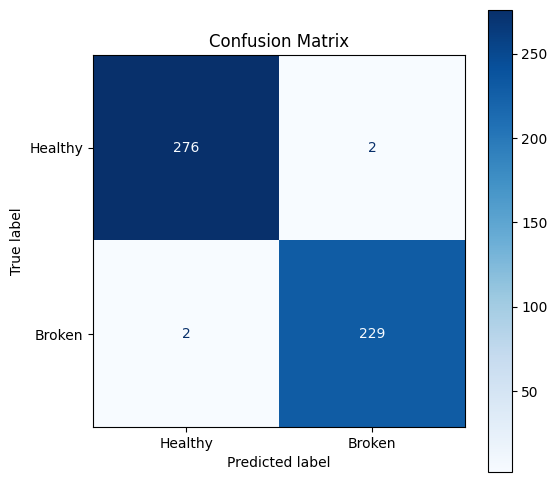

In [ ]:
print(classification_report(y_Test, y_pred, digits=4))

cm = confusion_matrix(y_Test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Healthy', 'Broken']
)

disp.plot(
    ax=ax,
    cmap="Blues",  # Color theme (e.g., 'Purples', 'Greens', 'viridis')
    values_format="d",  # Format values as integers ('d') or floats ('.2f')
)

plt.title("Confusion Matrix")
plt.show()